# 02 — Baseline Model Comparison

**Project:** Hospital Readmission Prediction  
**Dataset:** `hospital_readmissions.csv` — processed features (~25,000 rows)  
**Target:** `readmitted` (0/1) | positive rate ≈ 45.3%

| # | Section |
|---|---|
| 1 | Environment setup |
| 2 | Load features |
| 3 | Train/val/test split |
| 4 | Trivial baseline |
| 5 | Cross-validation |
| 6 | Train baselines on full training set |
| 7 | Evaluate on validation set |
| 8 | ROC and PR curves |
| 9 | Calibration curves |
| 10 | Feature importances |
| 11 | Model comparison |
| 12 | Save best baseline |

---
## 1 — Environment setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils import load_config, get_logger, set_seed, save_model

config = load_config(ROOT / 'config' / 'config.yaml')
set_seed(config['random_seed'])
config['_base_dir'] = str(ROOT)
config['_figures_subfolder'] = 'modeling'

logger = get_logger('02_modeling_baseline')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print(f'ROOT: {ROOT}')
print('Environment ready.')

ROOT: C:\Users\speak\HA_Project\Hospital-Readmission-Project-
Environment ready.


---
## 2 — Load features

The feature dataset is produced by running the pipeline:
`load_raw_data → clean_data → create_features → encode_features`
and saved to `data/processed/readmission_features.csv`.

In [2]:
# Build features CSV if not already present
feat_path = ROOT / config["paths"]["features_data"]
if not feat_path.exists():
    feat_path.parent.mkdir(parents=True, exist_ok=True)
    from src.data_preparation import load_raw_data, clean_data, encode_features
    from src.feature_engineering import create_features
    df_raw   = load_raw_data(ROOT / config["paths"]["raw_data"])
    df_clean = clean_data(df_raw, config)
    df_feat  = create_features(df_clean, config)
    df_enc   = encode_features(df_feat, config)
    df_enc.to_csv(feat_path, index=False)
    print(f"Saved {df_enc.shape[0]:,} rows x {df_enc.shape[1]} columns -> {feat_path}")
else:
    print(f"Features file exists: {feat_path}")

Features file exists: C:\Users\speak\HA_Project\Hospital-Readmission-Project-\data\processed\readmission_features.csv


In [3]:
from src.modeling import load_features

X, y, feature_names = load_features(config, base_dir=ROOT)
print(f'Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features')
print(f'Class balance: {y.mean()*100:.1f}% positive')
X.head()

2026-03-11 22:52:26 | INFO     | src.modeling | Loaded feature dataset: 25000 rows × 48 columns


2026-03-11 22:52:26 | INFO     | src.modeling | Feature matrix: 25000 rows × 47 features | pos=11754 (47.0%) neg=13246 (53.0%)


Feature matrix: 25,000 rows × 47 features
Class balance: 47.0% positive


,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,age_ordinal,any_n_inpatient,any_n_emergency,...,diag_3_Missing,diag_3_Musculoskeletal,diag_3_Other,diag_3_Respiratory,glucose_test_no,glucose_test_normal,A1Ctest_no,A1Ctest_normal,change_yes,diabetes_med_yes
0,8,72,1,18,2,0,0,4,0,0,...,0,0,1,0,1,0,1,0,0,1
1,3,34,2,13,0,0,0,4,0,0,...,0,0,1,0,1,0,1,0,0,1
2,5,45,0,18,0,0,0,2,0,0,...,0,0,0,0,1,0,1,0,1,1
3,2,36,0,12,1,0,0,4,0,0,...,0,0,0,0,1,0,1,0,1,1
4,1,42,0,7,0,0,0,3,0,0,...,0,0,0,1,1,0,1,0,0,1


---
## 3 — Train / val / test split

In [4]:
from src.modeling import make_splits

X_train, X_val, X_test, y_train, y_val, y_test = make_splits(X, y, config)

print(f'Train : {len(y_train):,}  ({y_train.mean()*100:.1f}% pos)')
print(f'Val   : {len(y_val):,}  ({y_val.mean()*100:.1f}% pos)')
print(f'Test  : {len(y_test):,}  ({y_test.mean()*100:.1f}% pos)')

2026-03-11 22:52:26 | INFO     | src.modeling | Split: train=15000 | val=5000 | test=5000


Train : 15,000  (47.0% pos)
Val   : 5,000  (47.0% pos)
Test  : 5,000  (47.0% pos)


---
## 4 — Trivial baseline

A majority-class classifier always predicts 1 (readmitted). With ≈45% positive rate, this achieves poor precision — establishing the floor.

In [5]:
from sklearn.metrics import classification_report

# Always-positive classifier
y_majority = np.ones(len(y_val), dtype=int)
print('Always-positive baseline (val set):')
print(classification_report(y_val, y_majority, target_names=['Not Readmitted', 'Readmitted']))
print(f'Accuracy: {(y_majority == y_val).mean():.3f}  (= positive rate ≈ {y_val.mean():.3f})')
print('\nThis is the floor — any model must substantially beat this.')

Always-positive baseline (val set):
                precision    recall  f1-score   support

Not Readmitted       0.00      0.00      0.00      2649
    Readmitted       0.47      1.00      0.64      2351

      accuracy                           0.47      5000
     macro avg       0.24      0.50      0.32      5000
  weighted avg       0.22      0.47      0.30      5000

Accuracy: 0.470  (= positive rate ≈ 0.470)

This is the floor — any model must substantially beat this.


---
## 5 — Cross-validation on training set

In [6]:
from src.modeling import build_baselines, cross_validate_model

models = build_baselines(config)
print(f'Models: {list(models.keys())}')

cv_results = {}
for name, model in models.items():
    print(f'\nCross-validating {name}...')
    cv_results[name] = cross_validate_model(model, X_train, y_train, config)

2026-03-11 22:52:26 | INFO     | src.modeling | Baseline estimators: ['LogisticRegression', 'RandomForest', 'GradientBoosting']


2026-03-11 22:52:26 | INFO     | src.modeling | Cross-validating Pipeline (5 folds)...


Models: ['LogisticRegression', 'RandomForest', 'GradientBoosting']

Cross-validating LogisticRegression...


2026-03-11 22:52:30 | INFO     | src.modeling |   CV roc_auc: 0.6448 ± 0.0082


2026-03-11 22:52:30 | INFO     | src.modeling |   CV average_precision: 0.6220 ± 0.0122


...

2026-03-11 22:52:35 | INFO     | src.modeling | Cross-validating HistGradientBoostingClassifier (5 folds)...



Cross-validating GradientBoosting...


2026-03-11 22:52:38 | INFO     | src.modeling |   CV roc_auc: 0.6532 ± 0.0078


2026-03-11 22:52:38 | INFO     | src.modeling |   CV average_precision: 0.6267 ± 0.0123


2026-03-11 22:52:38 | INFO     | src.modeling |   CV f1: 0.5813 ± 0.0083


In [7]:
# Summarise CV results
cv_summary = {}
for name, res in cv_results.items():
    cv_summary[name] = {
        'cv_roc_auc':  res['test_roc_auc'].mean(),
        'cv_pr_auc':   res['test_average_precision'].mean(),
        'cv_f1':       res['test_f1'].mean(),
    }

cv_df = pd.DataFrame(cv_summary).T.round(4)
cv_df.index.name = 'model'
print('Cross-validation summary (training set):')
display(cv_df.sort_values('cv_roc_auc', ascending=False))

Cross-validation summary (training set):


,cv_roc_auc,cv_pr_auc,cv_f1
model,,,
RandomForest,0.6556,0.6289,0.5874
GradientBoosting,0.6532,0.6267,0.5813
LogisticRegression,0.6448,0.6220,0.5515


---
## 6 — Train baselines on full training set

In [8]:
fitted_models = {}
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    fitted_models[name] = model

print('\nAll baselines trained.')

Training LogisticRegression...
Training RandomForest...


Training GradientBoosting...



All baselines trained.


---
## 7 — Evaluate on validation set

In [9]:
from src.modeling import evaluate

eval_results = {}
for name, model in fitted_models.items():
    metrics = evaluate(model, X_val, y_val, threshold=0.5)
    eval_results[name] = metrics
    print(f'{name}: ROC-AUC={metrics["roc_auc"]:.4f}  PR-AUC={metrics["pr_auc"]:.4f}  '
          f'Recall={metrics["recall"]:.4f}  Precision={metrics["precision"]:.4f}')

LogisticRegression: ROC-AUC=0.6504  PR-AUC=0.6276  Recall=0.5287  Precision=0.6123
RandomForest: ROC-AUC=0.6563  PR-AUC=0.6359  Recall=0.5746  Precision=0.5978
GradientBoosting: ROC-AUC=0.6579  PR-AUC=0.6351  Recall=0.5776  Precision=0.5954


In [10]:
from src.modeling import compare_models, select_best_model, plot_confusion_matrix

summary = compare_models(eval_results)
display(summary)

best_name = select_best_model(summary, metric='roc_auc')
best_model = fitted_models[best_name]
print(f'\nBest baseline: {best_name}')

# Save metrics
summary.to_csv(ROOT / config['paths']['metrics_out'])
print(f'Saved metrics to {config["paths"]["metrics_out"]}')

,roc_auc,pr_auc,accuracy,precision,recall,f1,specificity,brier
model,,,,,,,,
GradientBoosting,0.6579,0.6351,0.6168,0.5954,0.5776,0.5864,0.6516,0.2305
RandomForest,0.6563,0.6359,0.6182,0.5978,0.5746,0.5860,0.6569,0.2303
LogisticRegression,0.6504,0.6276,0.6210,0.6123,0.5287,0.5675,0.7029,0.2320


2026-03-11 22:52:41 | INFO     | src.modeling | Best model by roc_auc: GradientBoosting (0.6579)



Best baseline: GradientBoosting
Saved metrics to data/processed/metrics_summary.csv


In [11]:
# Confusion matrix for best model at default threshold
plot_confusion_matrix(
    best_model, X_val, y_val,
    model_name=best_name, config=config,
    threshold=0.5,
    filename='confusion_matrix_best_baseline.png'
)

2026-03-11 22:52:41 | INFO     | src.modeling | Saved confusion matrix → C:\Users\speak\HA_Project\Hospital-Readmission-Project-\reports\figures\modeling\confusion_matrix_best_baseline.png


---
## 8 — ROC and PR curves

In [12]:
from src.modeling import plot_roc_curves, plot_pr_curves

plot_roc_curves(
    fitted_models, X_val, y_val, config,
    title='ROC Curves — Baseline Models',
    filename='roc_curve_baselines.png'
)
plot_pr_curves(
    fitted_models, X_val, y_val, config,
    title='Precision-Recall Curves — Baseline Models',
    filename='pr_curve_baselines.png'
)

2026-03-11 22:52:41 | INFO     | src.modeling | Saved ROC curve → C:\Users\speak\HA_Project\Hospital-Readmission-Project-\reports\figures\modeling\roc_curve_baselines.png


2026-03-11 22:52:41 | INFO     | src.modeling | Saved PR curve → C:\Users\speak\HA_Project\Hospital-Readmission-Project-\reports\figures\modeling\pr_curve_baselines.png


---
## 9 — Calibration curves

In [13]:
from src.modeling import plot_calibration_curves

plot_calibration_curves(fitted_models, X_val, y_val, config,
                         filename='calibration_baselines.png')

2026-03-11 22:52:42 | INFO     | src.modeling | Saved calibration curves → C:\Users\speak\HA_Project\Hospital-Readmission-Project-\reports\figures\modeling\calibration_baselines.png


---
## 10 — Feature importances

In [14]:
from src.modeling import plot_feature_importance

for name, model in fitted_models.items():
    plot_feature_importance(model, feature_names, name, config, top_n=20)

2026-03-11 22:52:42 | INFO     | src.modeling | Saved feature importance → C:\Users\speak\HA_Project\Hospital-Readmission-Project-\reports\figures\modeling\feature_importance_logisticregression.png


2026-03-11 22:52:42 | INFO     | src.modeling | Saved feature importance → C:\Users\speak\HA_Project\Hospital-Readmission-Project-\reports\figures\modeling\feature_importance_randomforest.png


2026-03-11 22:52:42 | INFO     | src.modeling | No feature importance available for GradientBoosting — skipping.


---
## 11 — Model comparison

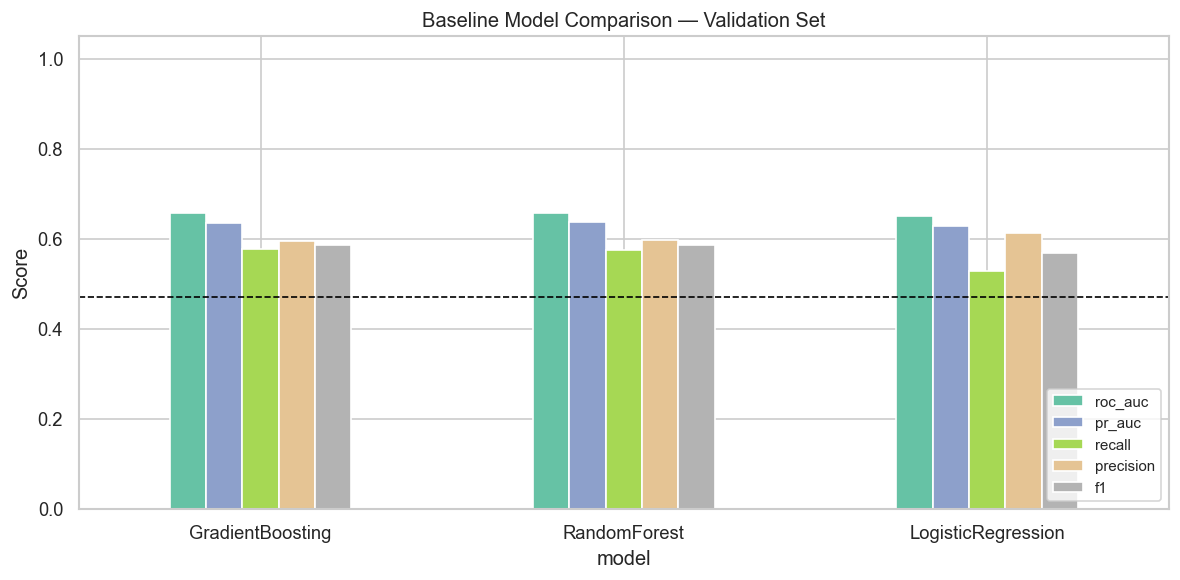

In [15]:
# Bar chart comparing key metrics
metrics_to_plot = ['roc_auc', 'pr_auc', 'recall', 'precision', 'f1']
avail = [m for m in metrics_to_plot if m in summary.columns]

fig, ax = plt.subplots(figsize=(10, 5))
summary[avail].plot.bar(ax=ax, rot=0, colormap='Set2')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Baseline Model Comparison — Validation Set')
ax.legend(loc='lower right', fontsize=9)
ax.axhline(y_val.mean(), color='black', linestyle='--', lw=1,
           label='Positive rate (no-skill)')

figures_dir = ROOT / config['paths']['figures_dir'] / 'modeling'
figures_dir.mkdir(parents=True, exist_ok=True)
fig.tight_layout()
fig.savefig(figures_dir / 'metrics_comparison_baselines.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12 — Save best baseline model

In [16]:
model_path = ROOT / config['paths']['model_dir'] / 'best_baseline_model.pkl'
save_model(best_model, model_path)
print(f'Saved best baseline ({best_name}) to {model_path}')
print(f'Val ROC-AUC: {eval_results[best_name]["roc_auc"]:.4f}')
print('\nNext: run 03_model_tuning.ipynb')

Saved best baseline (GradientBoosting) to C:\Users\speak\HA_Project\Hospital-Readmission-Project-\models\best_baseline_model.pkl
Val ROC-AUC: 0.6579

Next: run 03_model_tuning.ipynb
